In [1]:
# DEFAULT
import numpy as np
import pickle
from collections import defaultdict

# CUSTOM
from cora.momenta import get_max_momentum_list, get_sel_momentum_list, get_sel_momentum_indices
from hadrana.misc.lhpc.lhpc_visualise import *

In [2]:
def dd():
    return defaultdict(dd)

In [3]:
ensemble    = 'C102'
cur         = 'Z'
pol         = 'Z'
n_bst       = 100

nsquares    = [0, 1, 2, 3, 4, 5, 6, 8]
source_sets = ['3', '4']

In [4]:
# data was saved as e.g. H106-RATIOS-AXIAL-CURZ-POLZ-NSQUARE0-NBST100-SOURCE-SET2.pkl

def load_ratios(ensemble, nsquare, source_set):
    tag  = f"{ensemble}-RATIOS-AXIAL-CUR{cur}-POL{pol}-NSQUARE{nsquare}-NBST{n_bst}-SOURCE-SET{source_set}.pkl"
    path = f"/glurch/scratch/kic04594/bootstrap_data/lhp_vs_reg/{ensemble}/axial/{tag}"
    with open(path, "rb") as f:
        return pickle.load(f)

ratios = dd()
for s in source_sets:
    for n in nsquares:
        ratios[s][n] = load_ratios(ensemble, n, s)

In [5]:
max_momentum_list    = get_max_momentum_list(8)
print(f"Total Available momentum configurations: {len(max_momentum_list)}")
print(max_momentum_list)
print()

for n in nsquares:
    print(f">> nsquare = {n}")
    sel_momentum_list    = get_sel_momentum_list(n)
    sel_momentum_indices = get_sel_momentum_indices(n, None)

    print(f"Available momentum configurations")
    print(sel_momentum_list)
    print(f"Corresponding indices")
    print(sel_momentum_indices)
    print(f"Total: {len(sel_momentum_list)}")
    print()

Total Available momentum configurations: 93
[(0, 0, 0), (0, 0, 1), (0, 0, -1), (0, 0, 2), (0, 0, -2), (0, 1, 0), (0, -1, 0), (0, 1, 1), (0, -1, 1), (0, 1, -1), (0, -1, -1), (0, 1, 2), (0, -1, 2), (0, 1, -2), (0, -1, -2), (0, 2, 0), (0, -2, 0), (0, 2, 1), (0, -2, 1), (0, 2, -1), (0, -2, -1), (0, 2, 2), (0, -2, 2), (0, 2, -2), (0, -2, -2), (1, 0, 0), (-1, 0, 0), (1, 0, 1), (-1, 0, 1), (1, 0, -1), (-1, 0, -1), (1, 0, 2), (-1, 0, 2), (1, 0, -2), (-1, 0, -2), (1, 1, 0), (-1, 1, 0), (1, -1, 0), (-1, -1, 0), (1, 1, 1), (-1, 1, 1), (1, -1, 1), (1, 1, -1), (1, -1, -1), (-1, 1, -1), (-1, -1, 1), (-1, -1, -1), (1, 1, 2), (-1, 1, 2), (1, -1, 2), (1, 1, -2), (1, -1, -2), (-1, 1, -2), (-1, -1, 2), (-1, -1, -2), (1, 2, 0), (-1, 2, 0), (1, -2, 0), (-1, -2, 0), (1, 2, 1), (-1, 2, 1), (1, -2, 1), (1, 2, -1), (1, -2, -1), (-1, 2, -1), (-1, -2, 1), (-1, -2, -1), (2, 0, 0), (-2, 0, 0), (2, 0, 1), (-2, 0, 1), (2, 0, -1), (-2, 0, -1), (2, 0, 2), (-2, 0, 2), (2, 0, -2), (-2, 0, -2), (2, 1, 0), (-2, 1, 0), (2,

In [6]:
ratios_per_nsquare = dd()
for s in source_sets:
    for n in nsquares:
        src_snk_seps         = list(ratios[s][n].keys())
        sel_momentum_indices = get_sel_momentum_indices(n, None)
        for t in src_snk_seps:
            ratios_per_nsquare[s][n][t] = np.mean(
                ratios[s][n][t][:, :, sel_momentum_indices, :], axis=2
            )

In [7]:
def x_vals(nsquare: int, tsep: int):
    n_tau = tsep + 1
    if nsquare == 0:
        x = np.arange(n_tau) - (n_tau - 1) / 2
    else:
        x = np.arange(n_tau)
    return x

def y_est_err(data: dict, src_id: int, nsquare: int, tsep: int):
    y_bst = data[nsquare][tsep]
    y_est = np.mean(y_bst[:, src_id, :], axis=0)
    y_err = np.std(y_bst[:, src_id, :], axis=0, ddof=1)
    return y_est, y_err

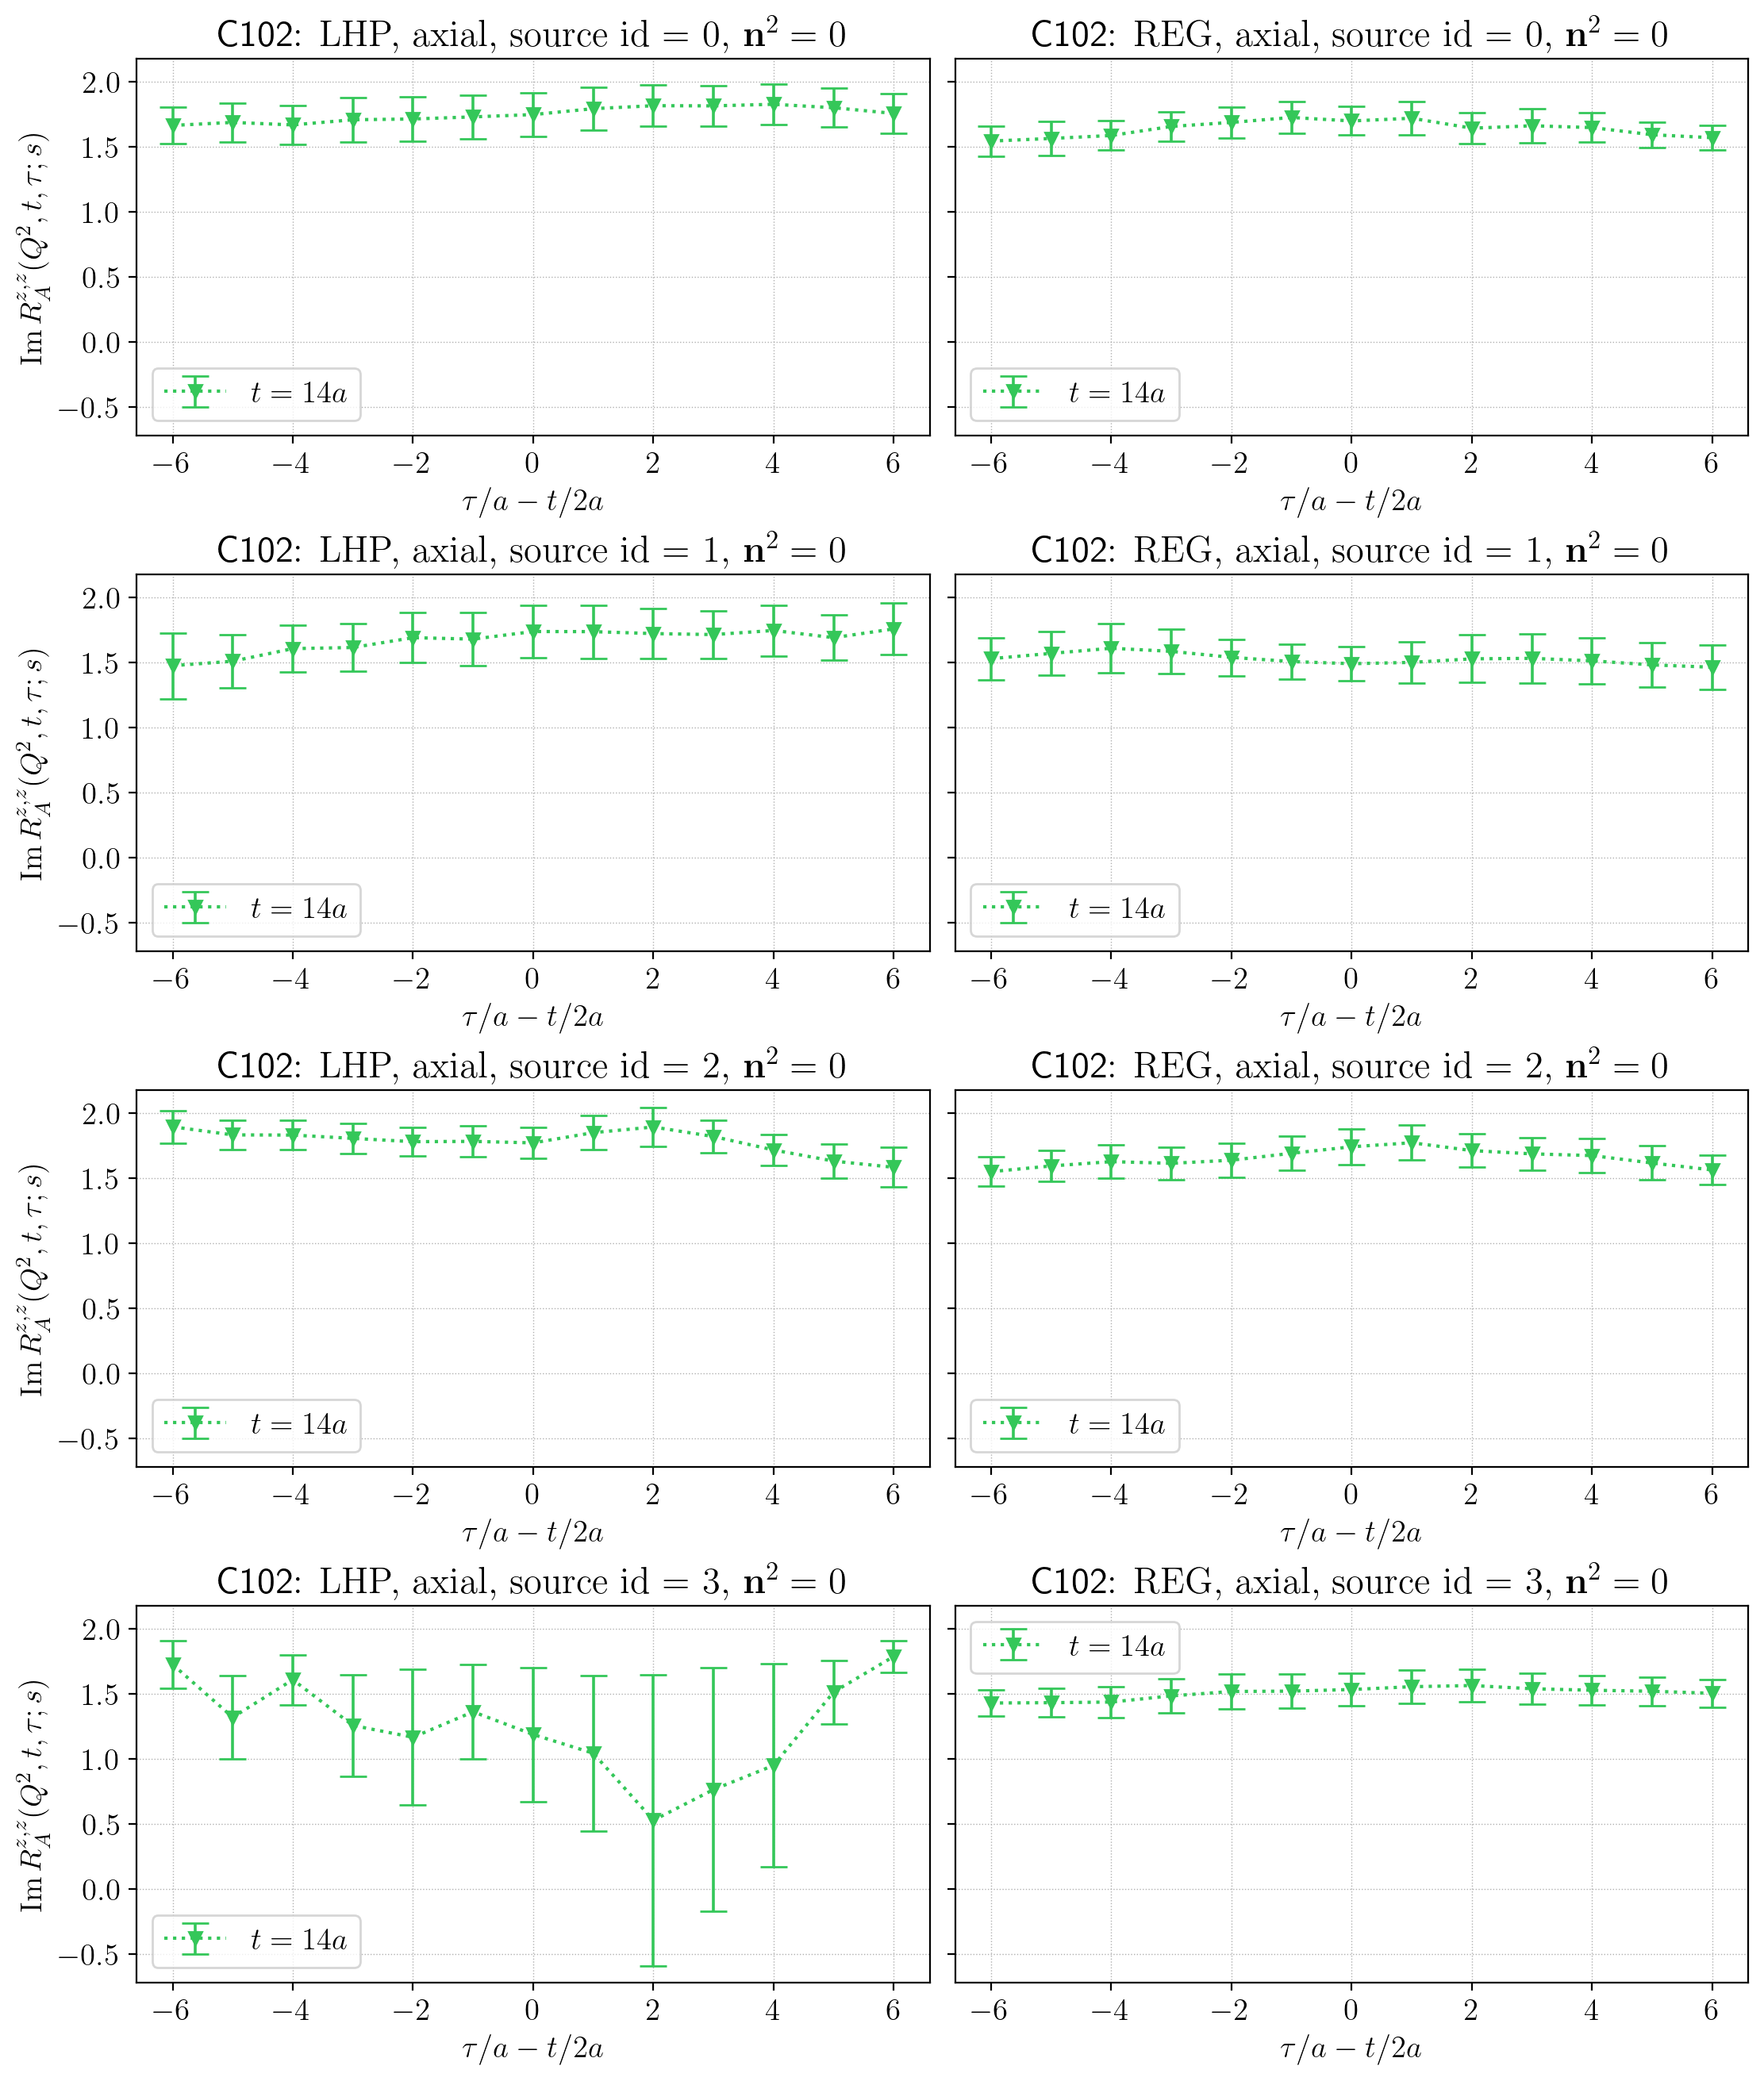

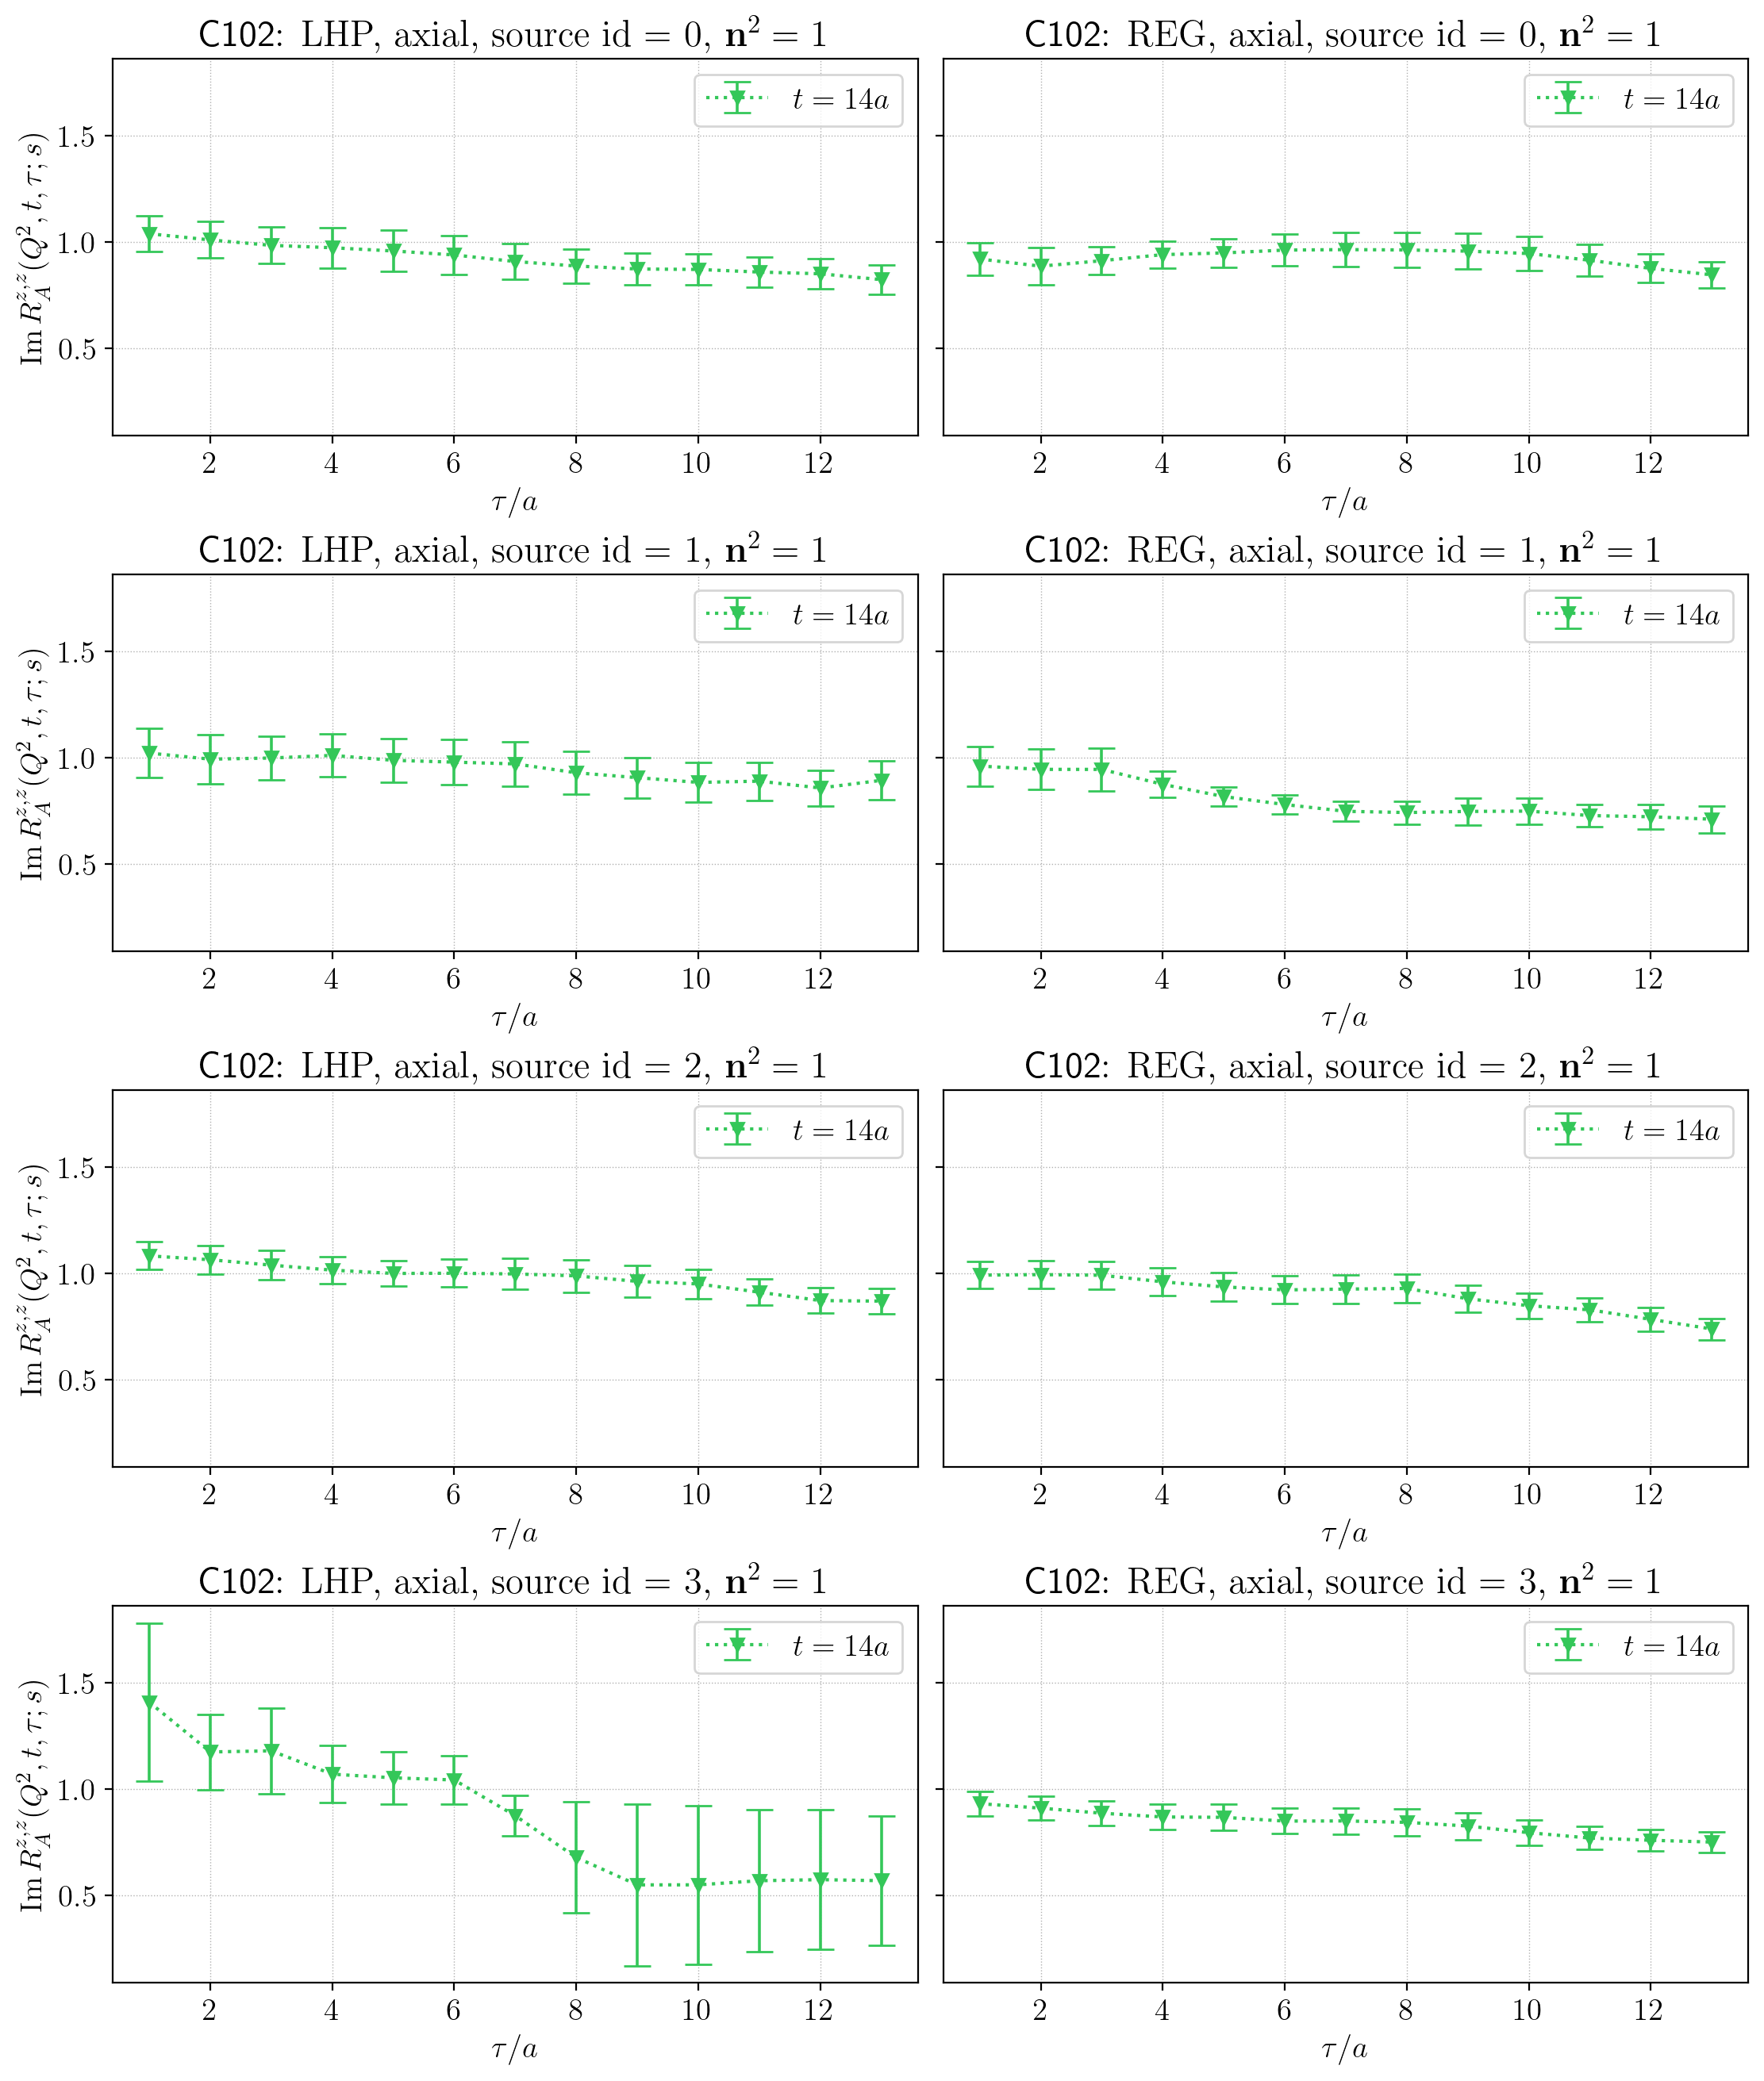

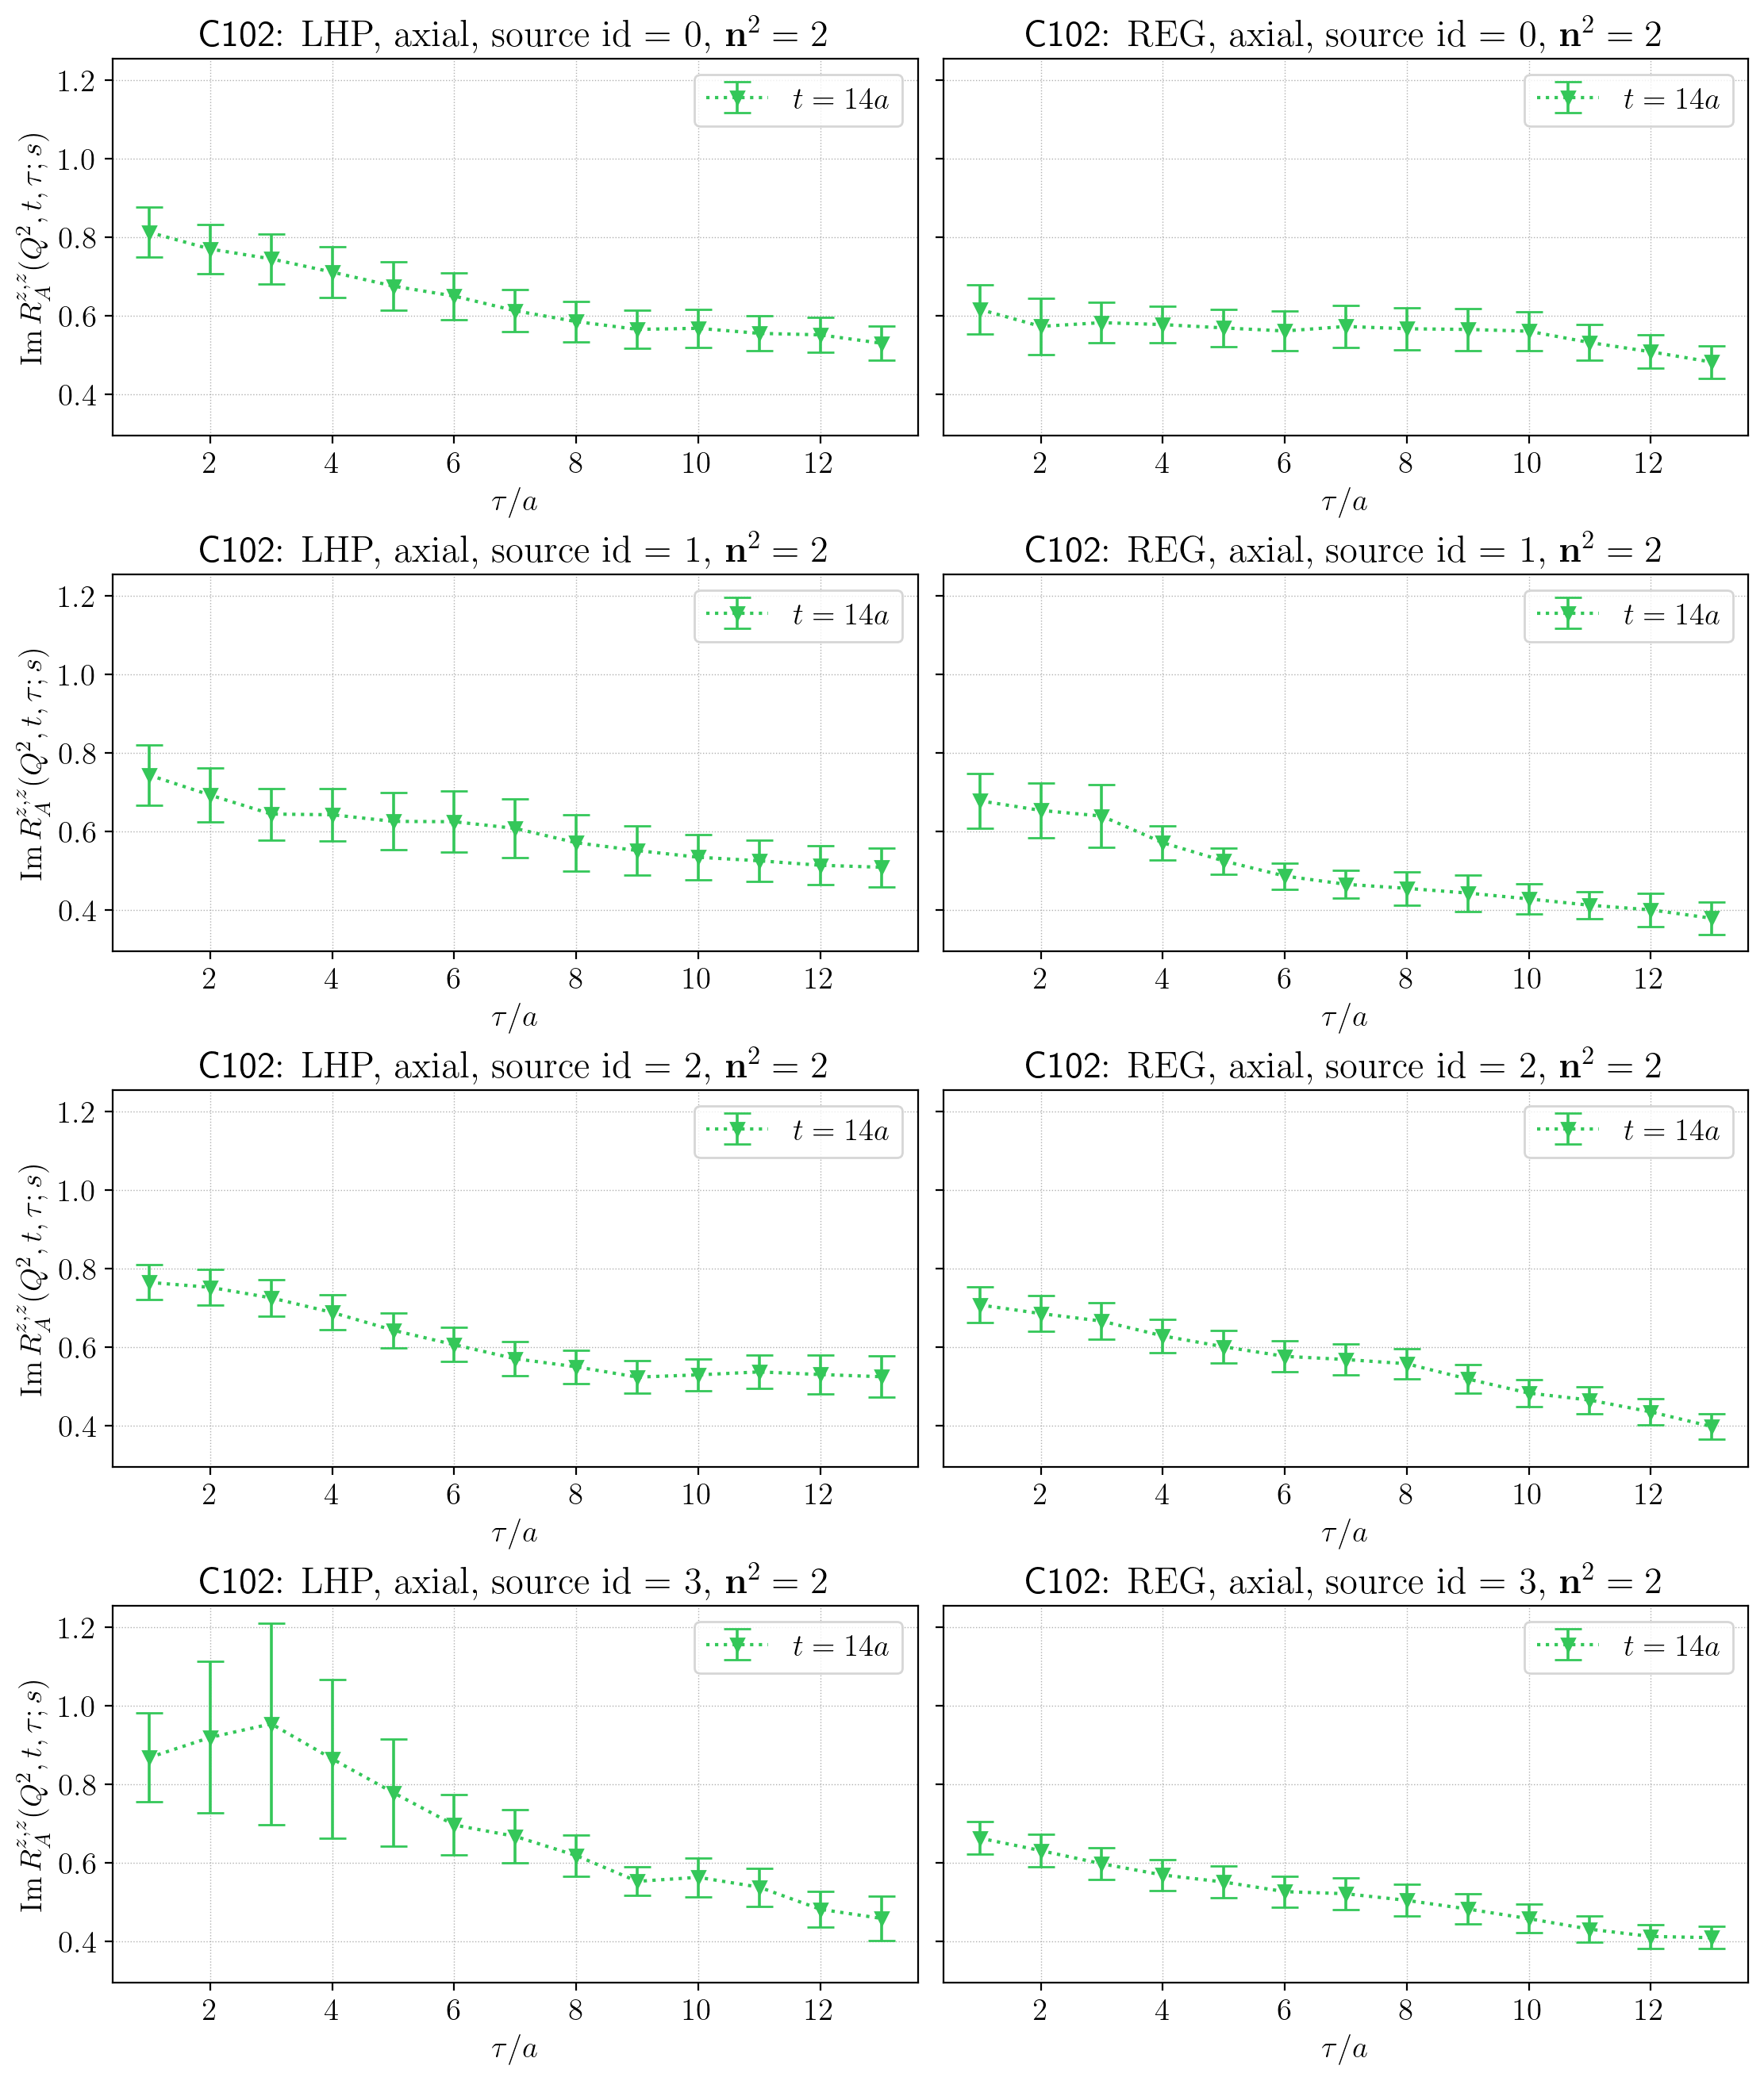

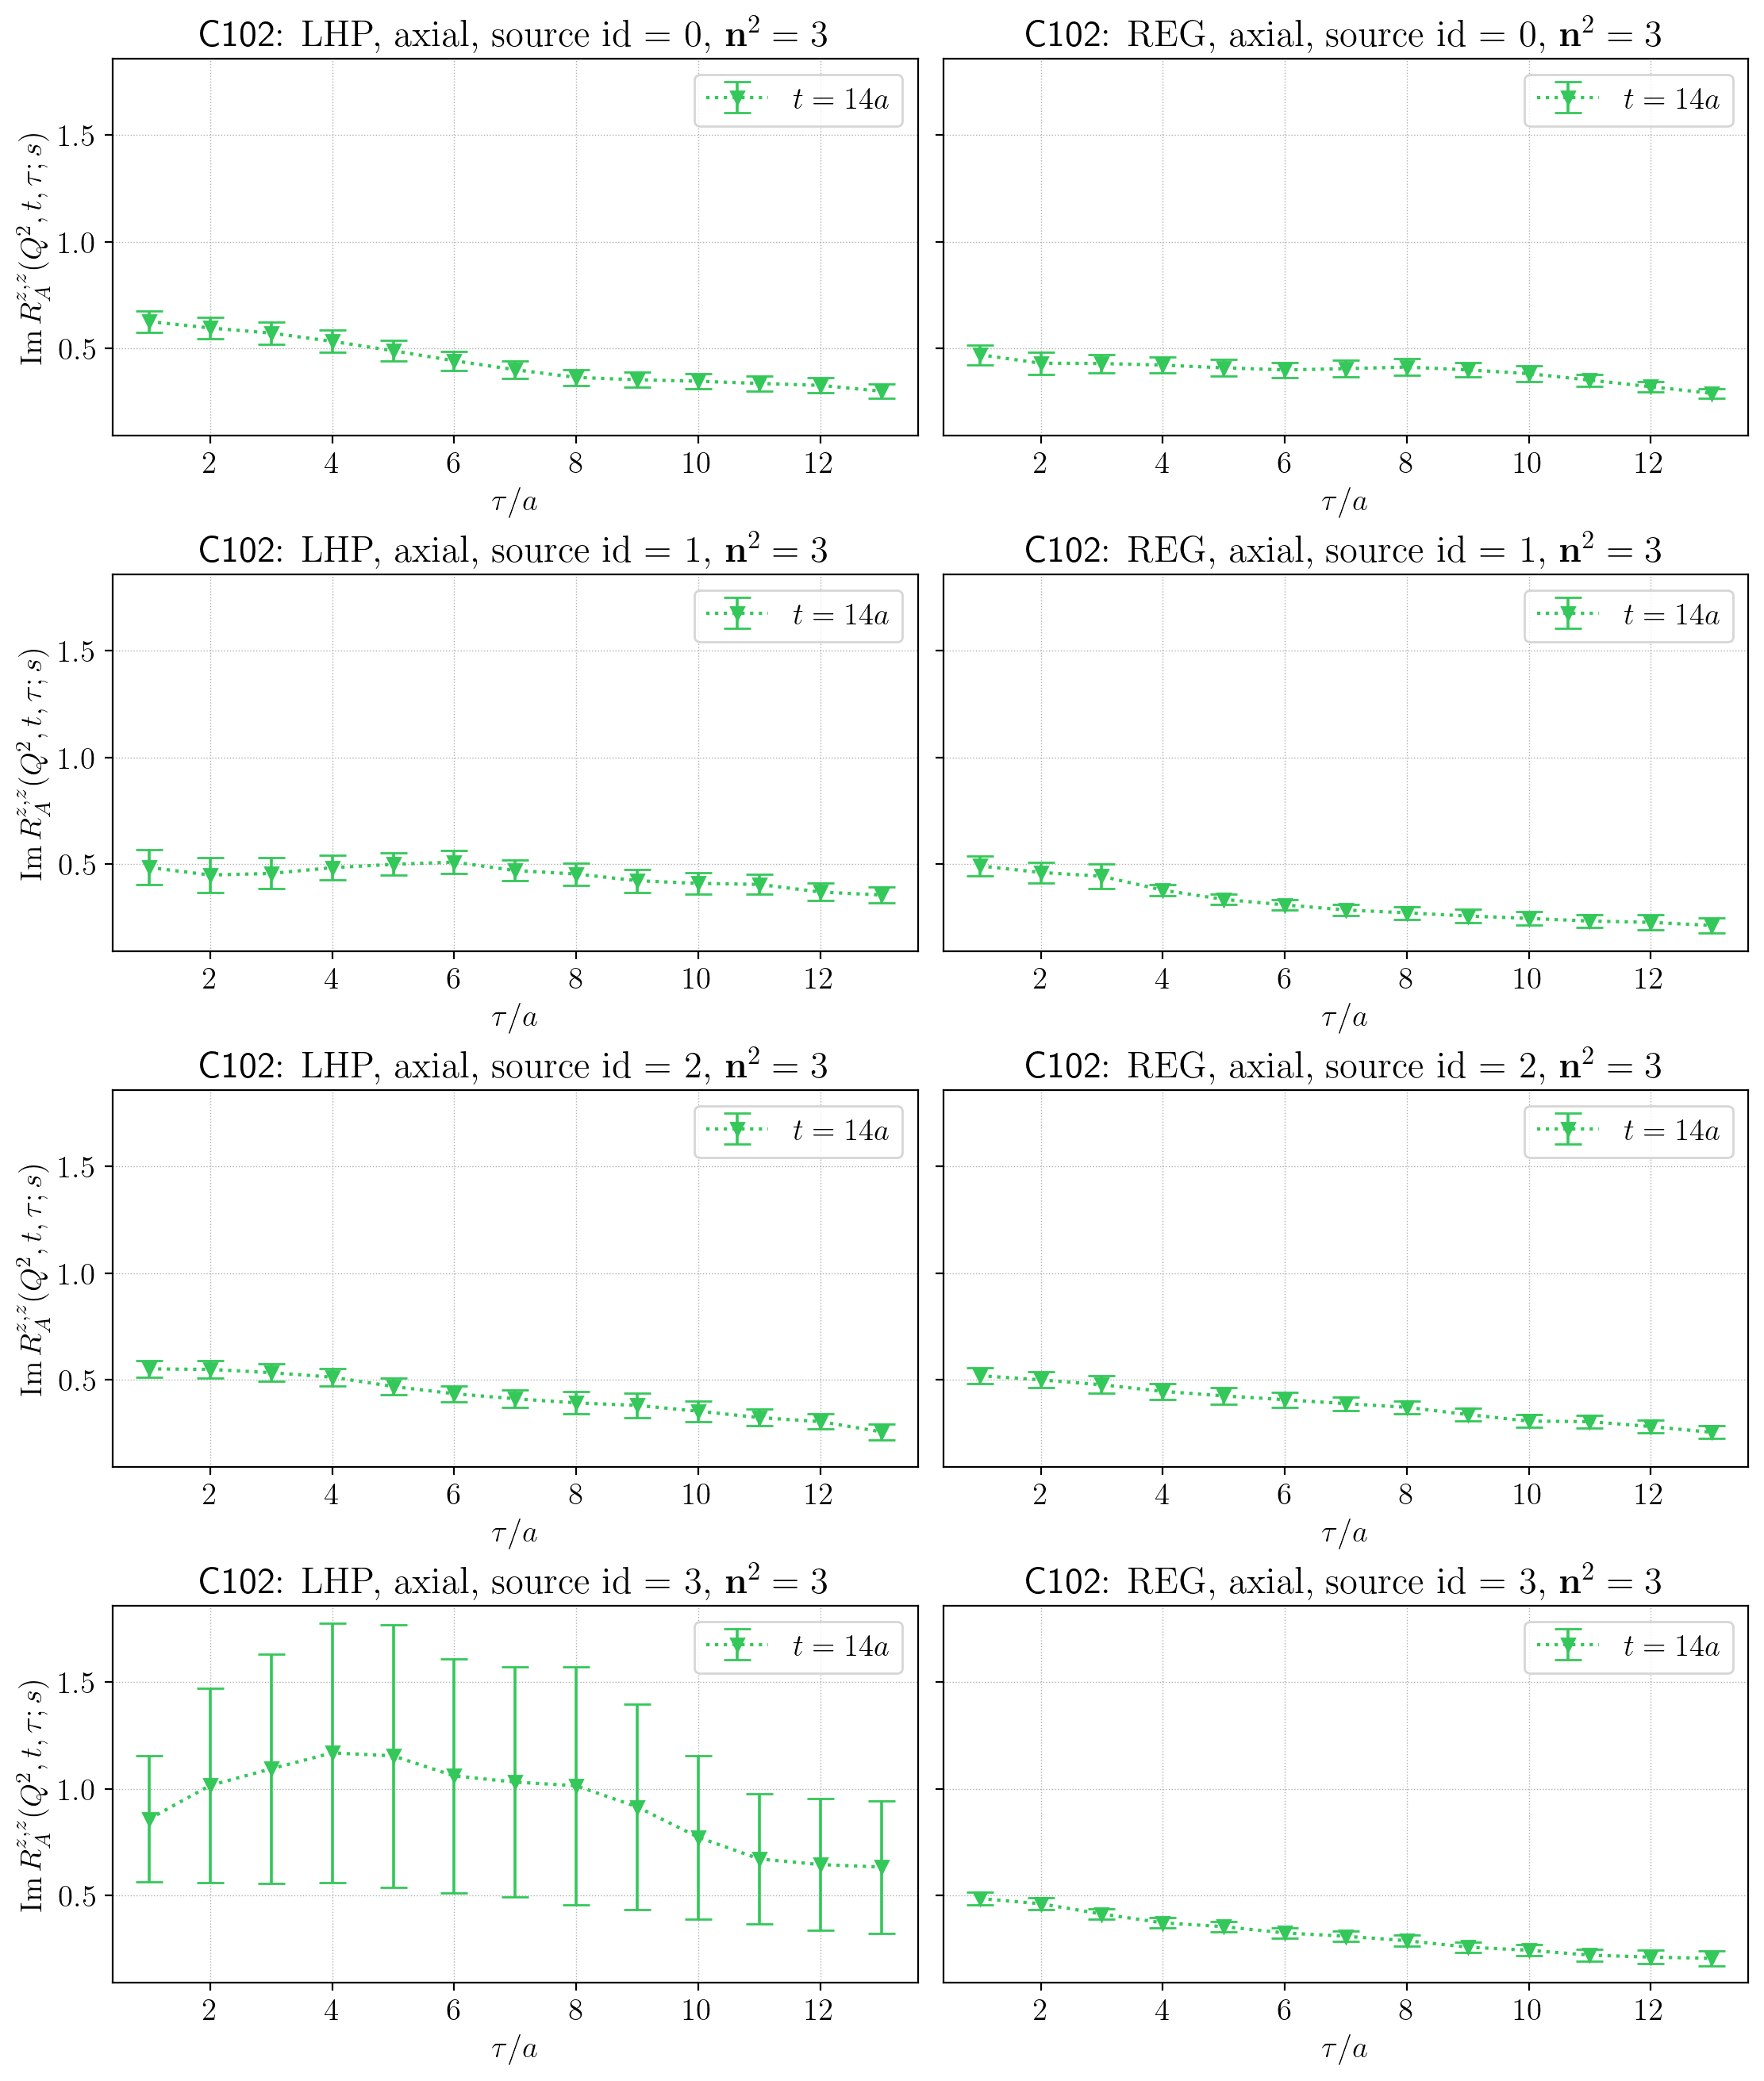

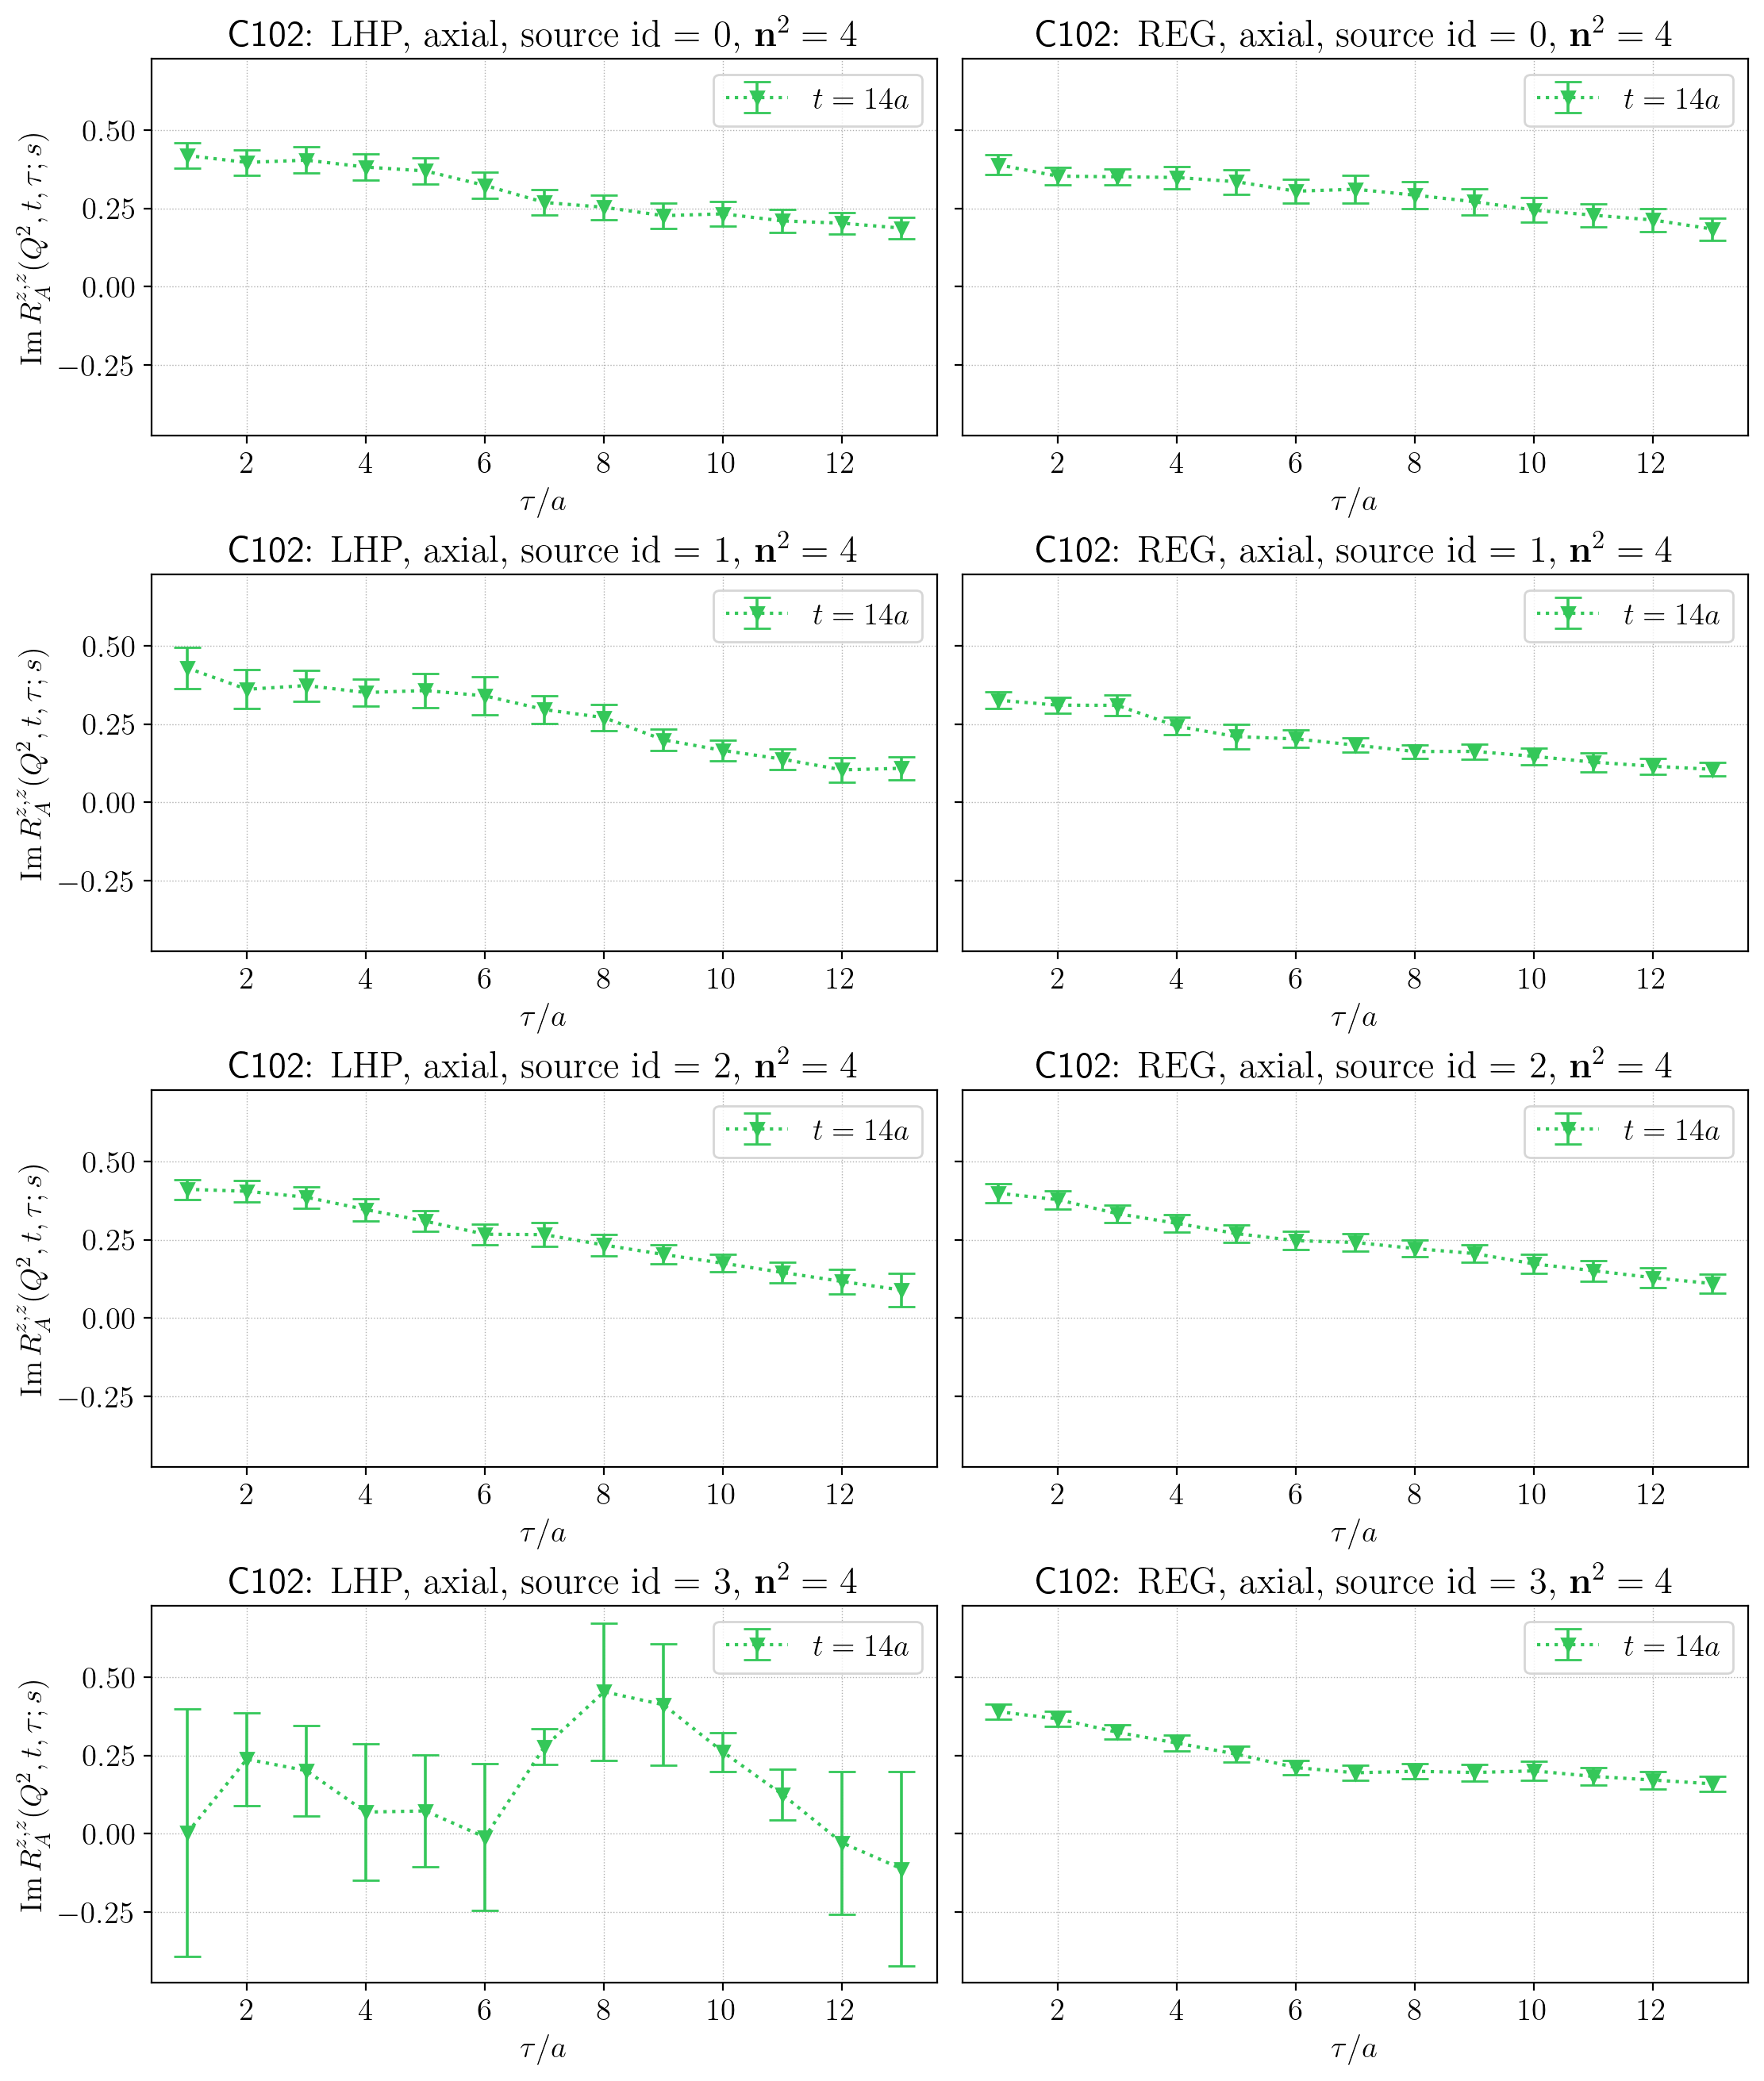

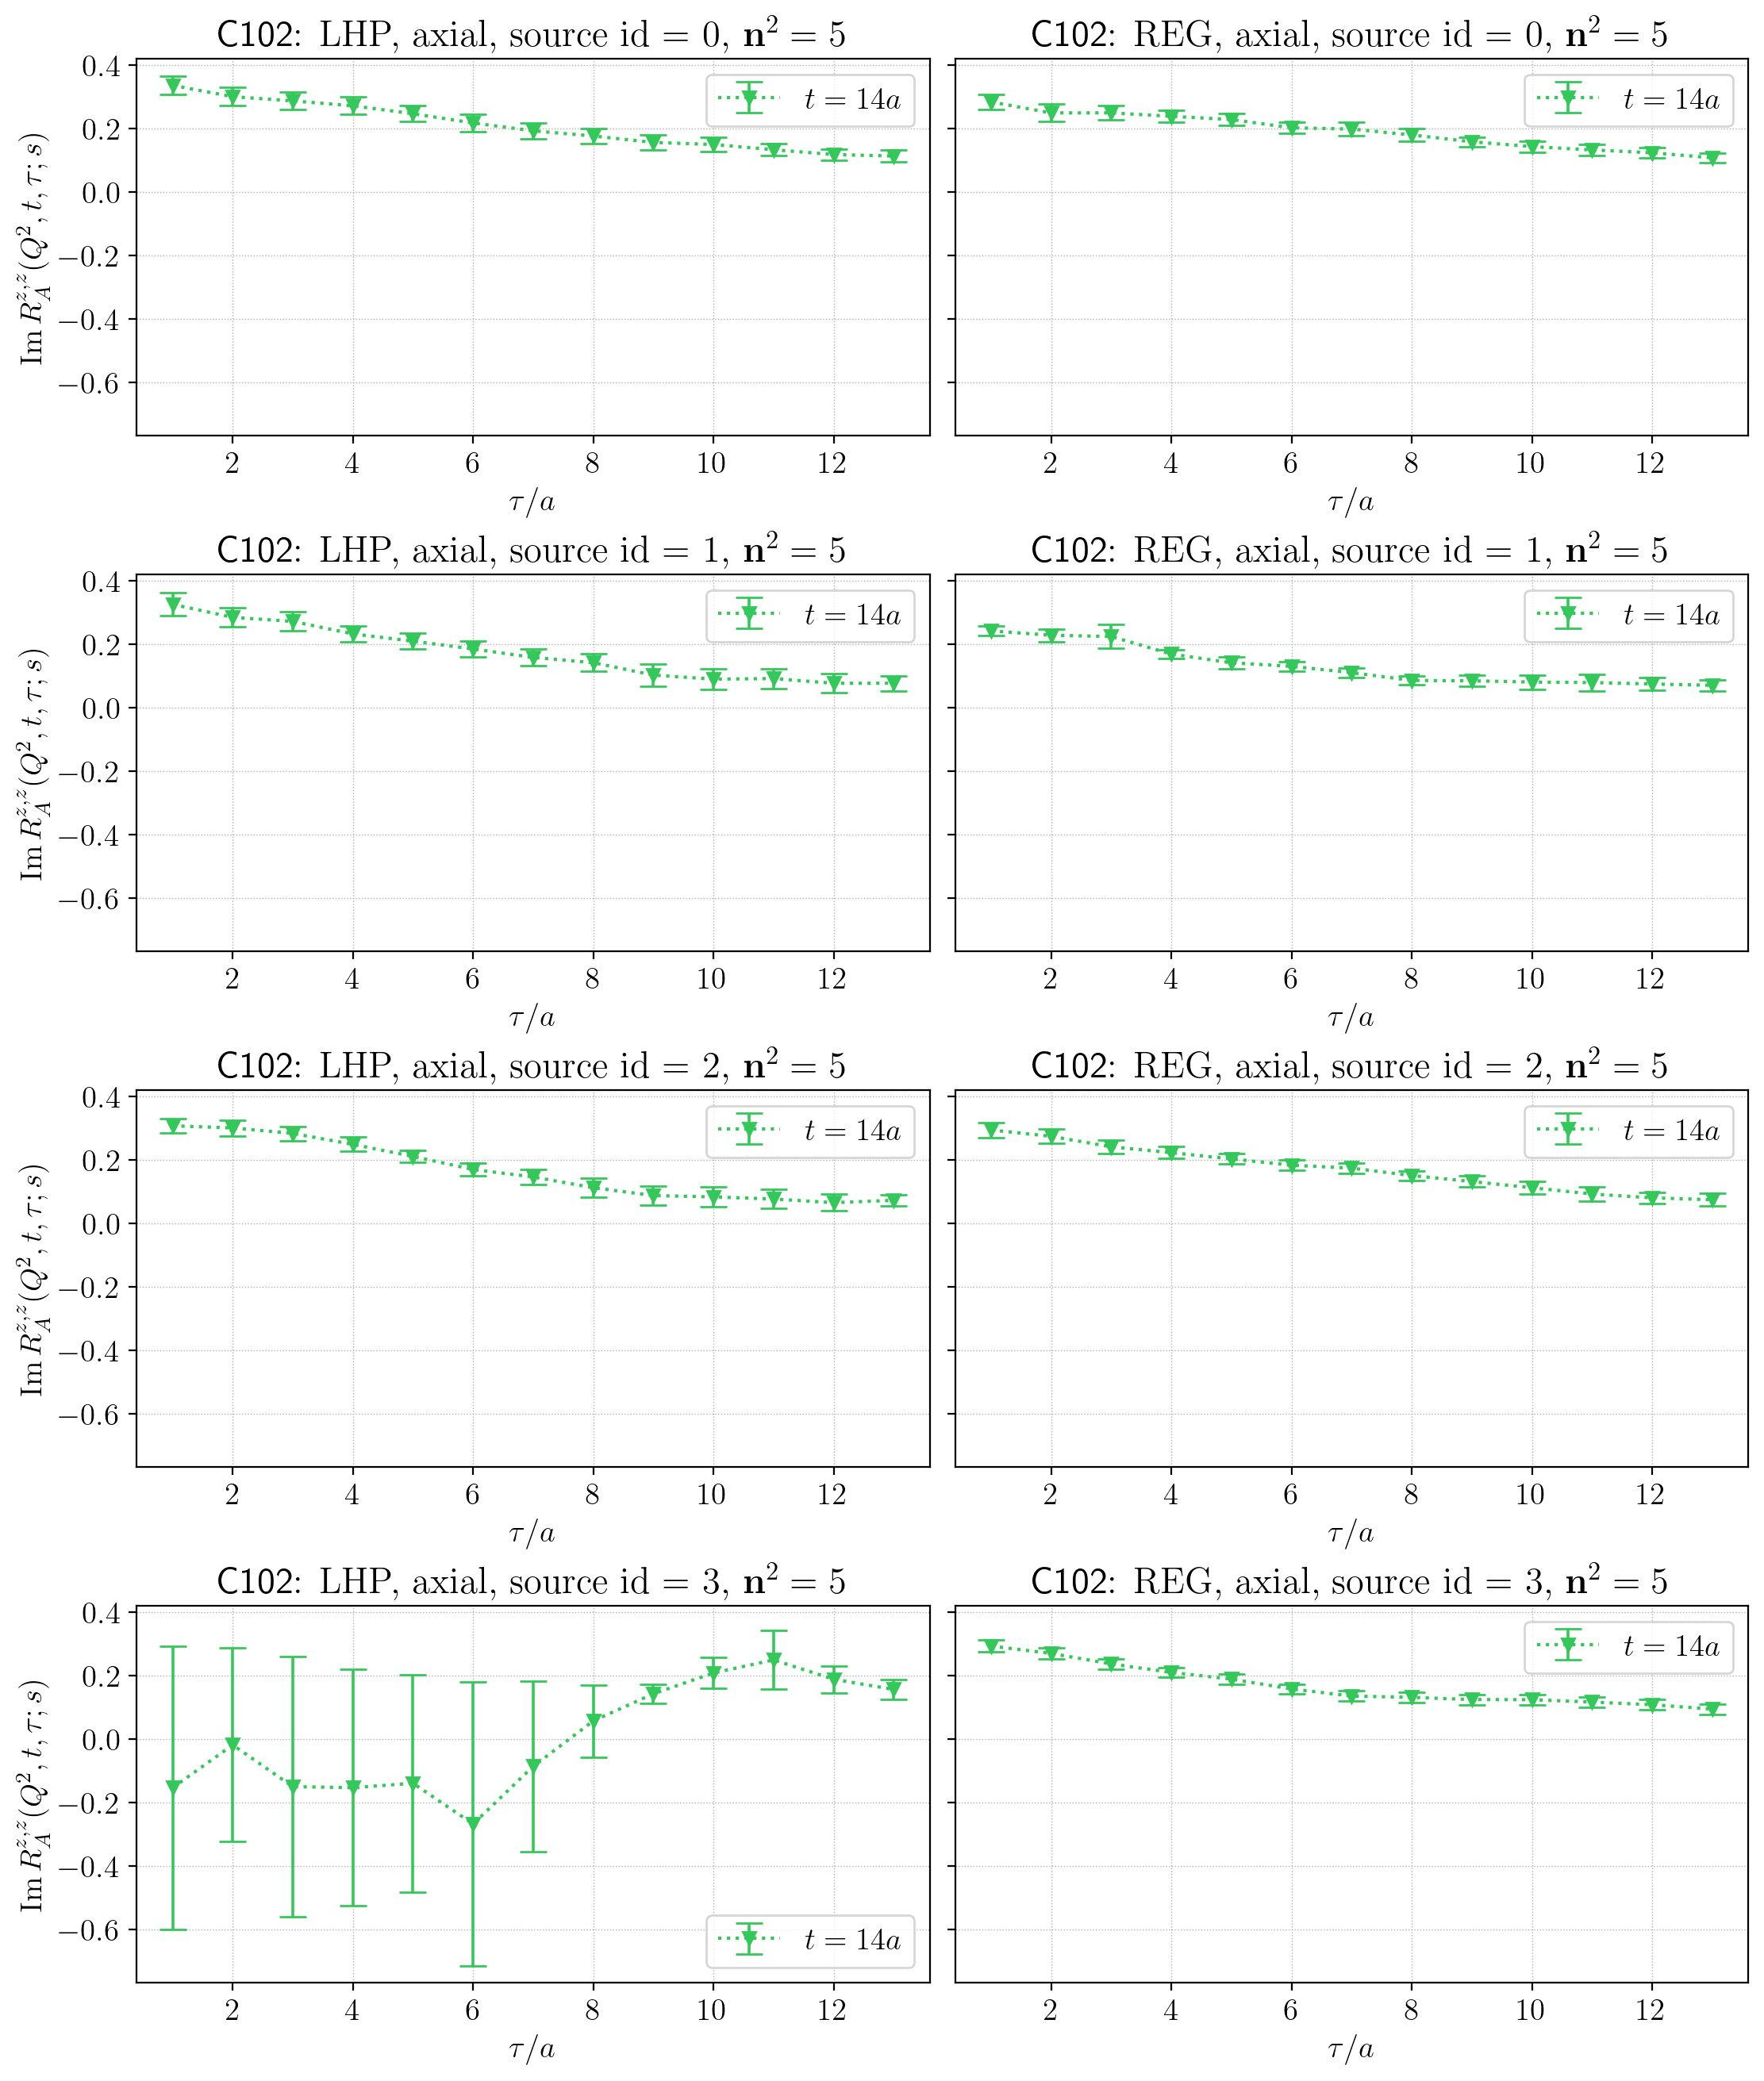

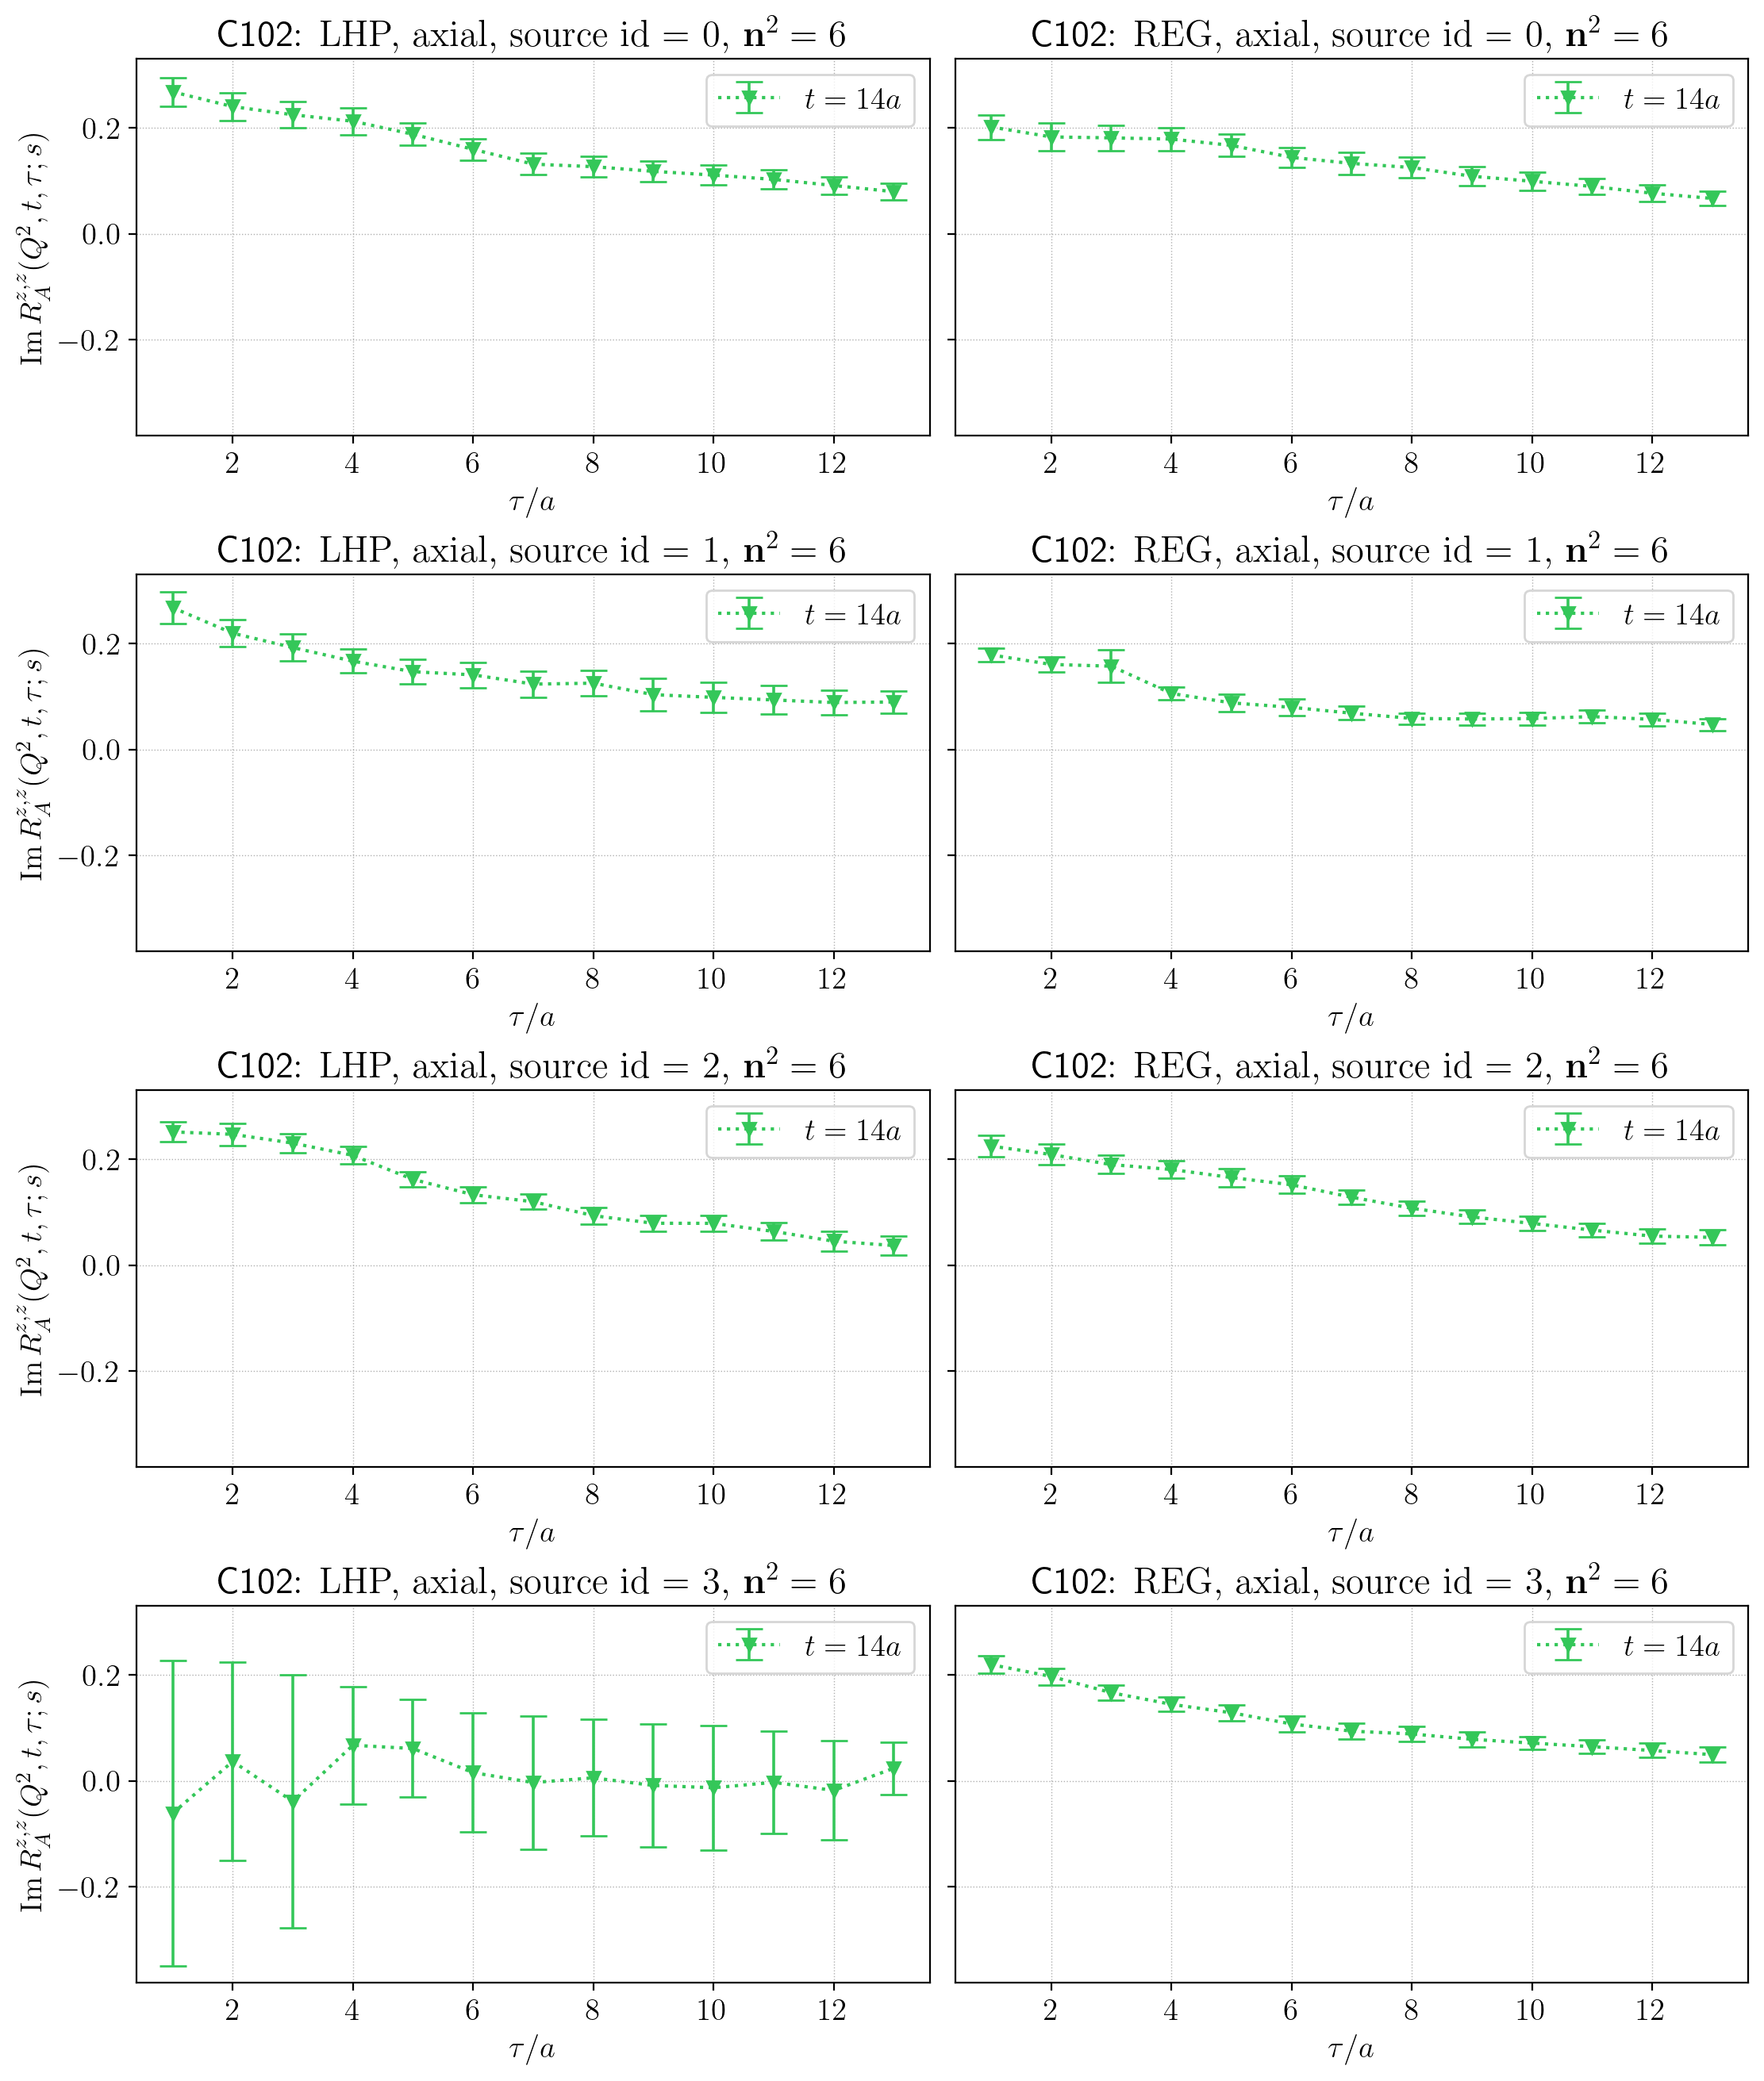

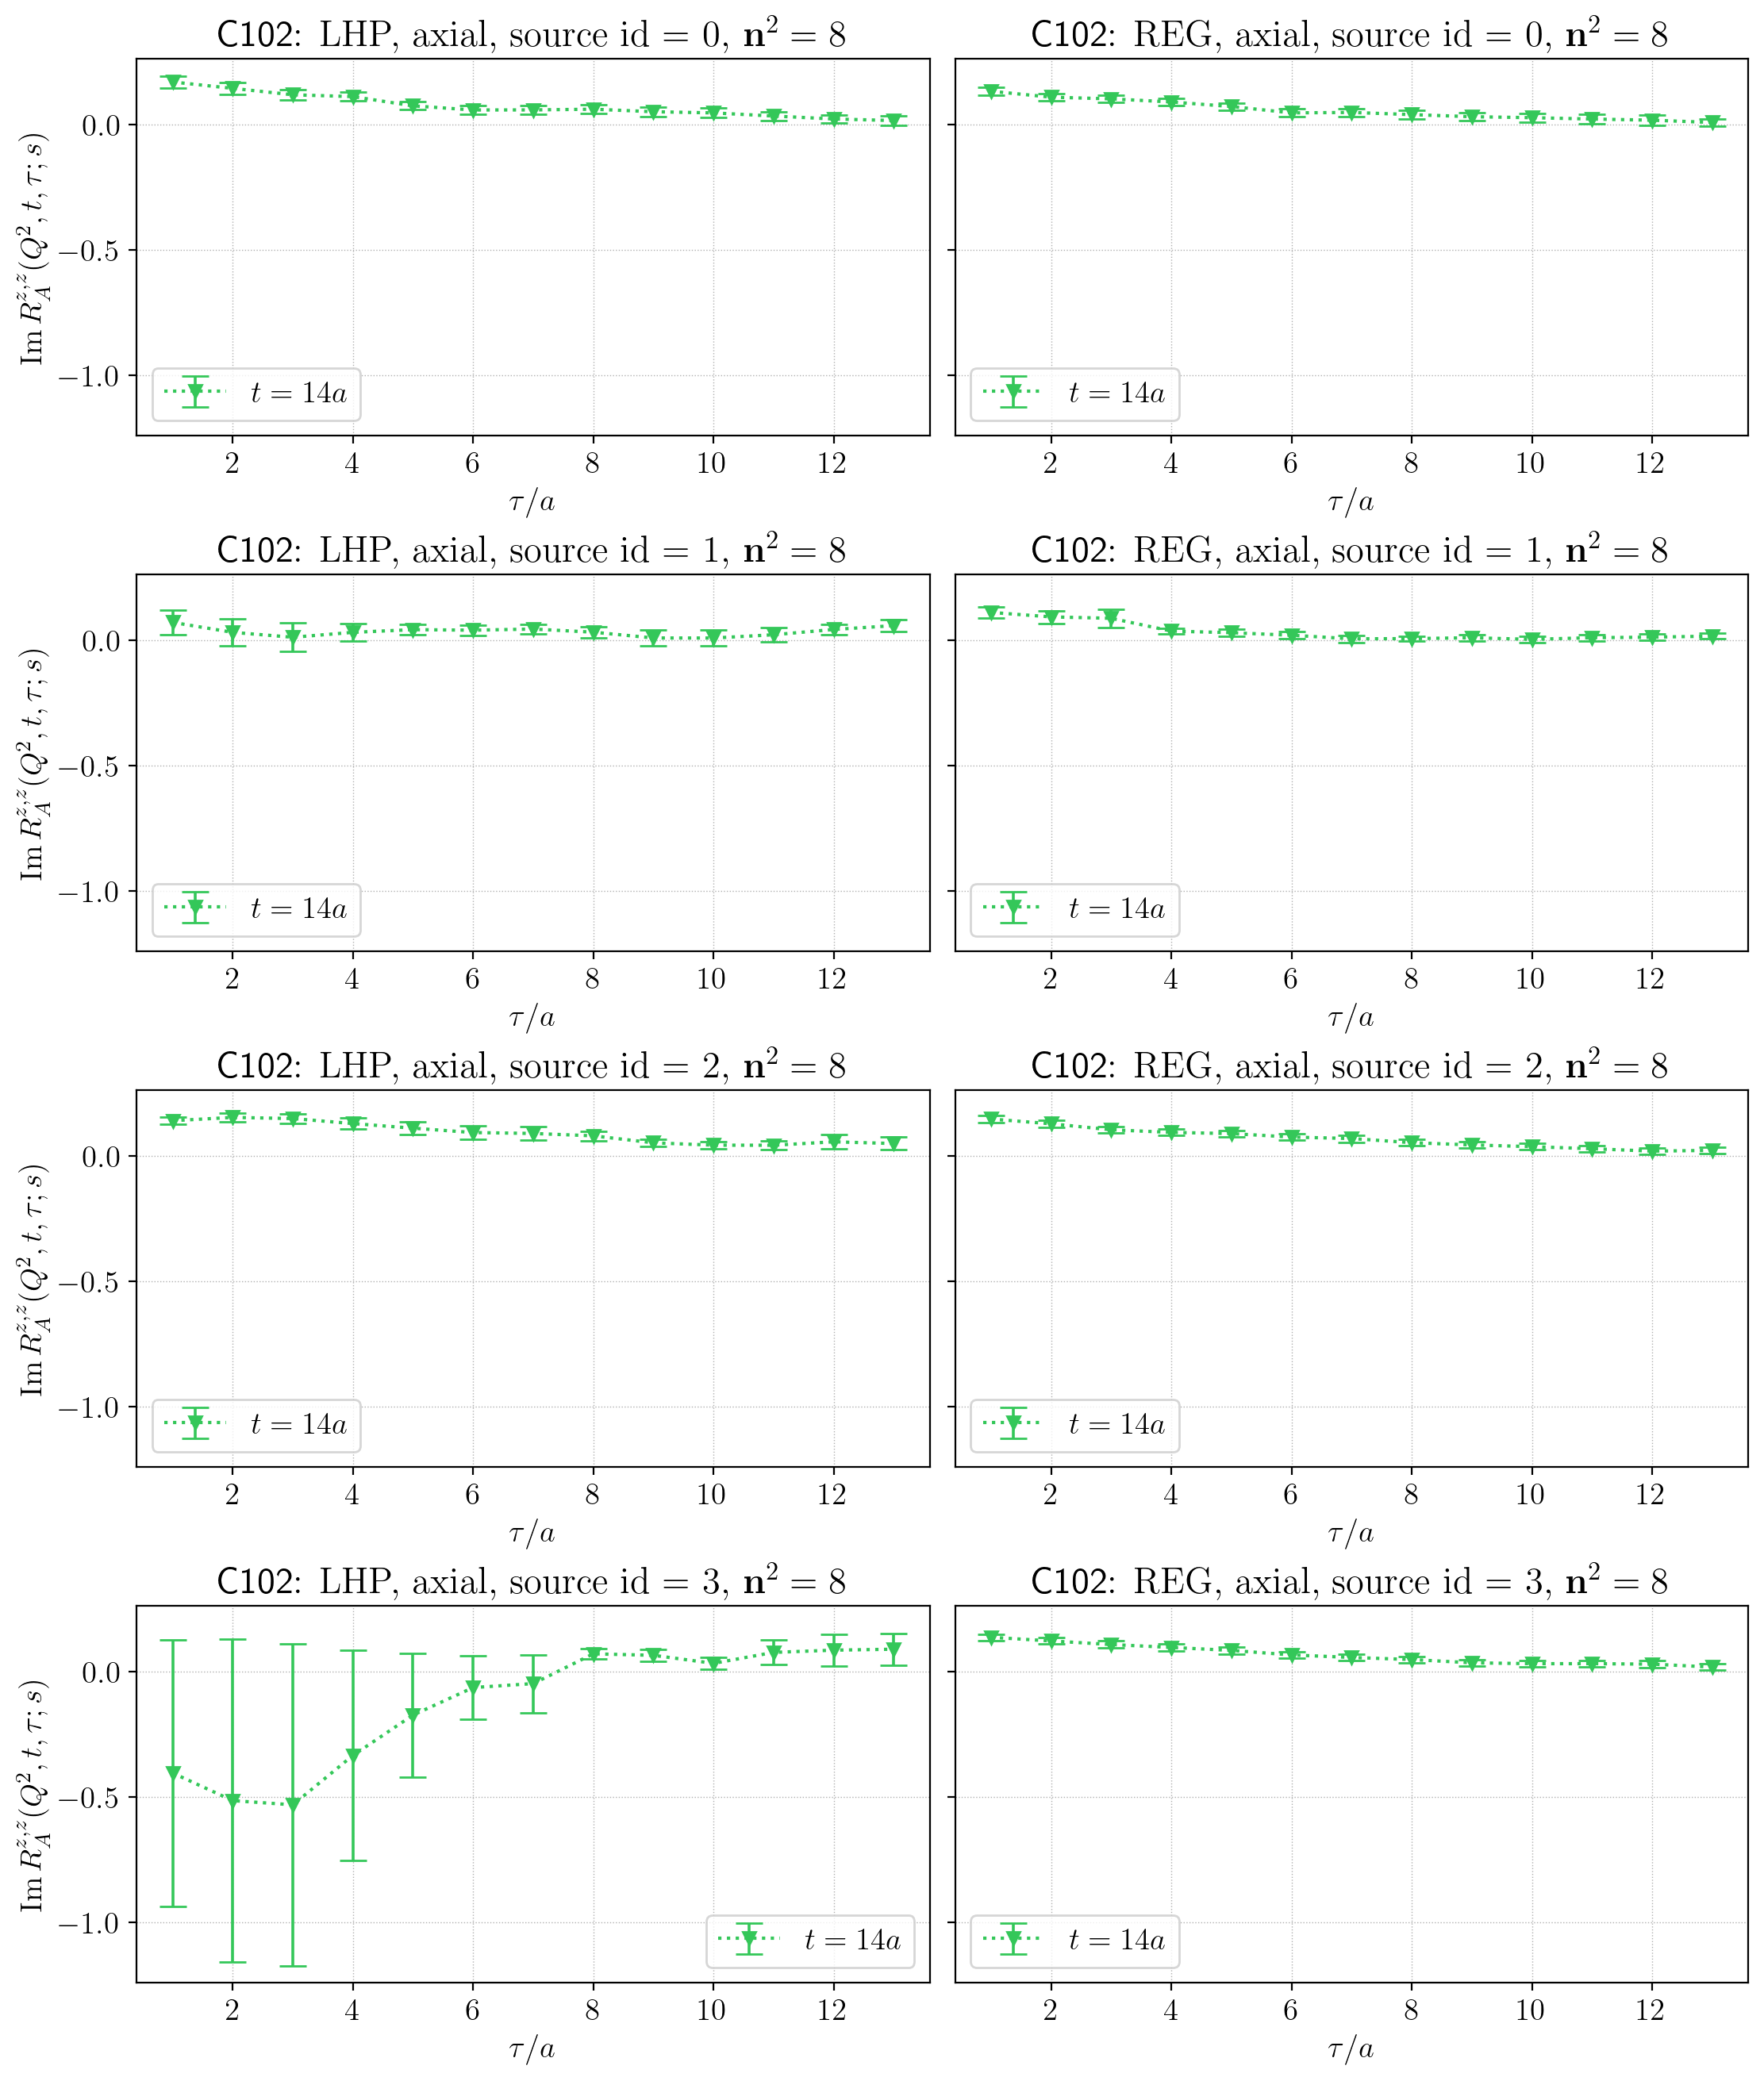

In [8]:
src_ids = [0,1,2,3]

for n in nsquares:
    fig, axs = plt.subplots(
        nrows=len(src_ids),
        ncols=2,
        figsize=(11,13),
        sharey=True,
        constrained_layout=True
    )

    for row, src_id in enumerate(src_ids):
        for col, (label, ratios, src_set) in enumerate([
            ("LHP", ratios_per_nsquare['3'], f"SOURCE-SET3"),
            ("REG", ratios_per_nsquare['4'], f"SOURCE-SET4"),
        ]):
            ax = axs[row, col]
            ax.set_title(
                    rf"$\mathsf{{{ensemble}}}$: {label}, axial, source id = {src_id}, "
                    rf"$\mathbf{{n}}^2 = {n}$"
                )

            # only t=14 has comparable data
            for t in [14]:
                x            = x_vals(n, t)
                y_est, y_err = y_est_err(ratios, src_id, n, t)

                colour = t_color[t]
                marker = t_marker[t]

                ax.errorbar(
                    x[1:-1],
                    y_est[1:-1],
                    y_err[1:-1],
                    marker=marker,
                    markersize=6,
                    capsize=6,
                    color=colour,
                    linestyle=":",
                    elinewidth=elinewidth,
                    label=rf"$t={t}a$"
                )

                ax.grid(True, linestyle=":", linewidth=0.5)

                ax.set_xlabel(r"$\tau/a - t/2a$" if n == 0 else r"$\tau/a$")

                if col == 0:
                    ax.set_ylabel(r"$\mathrm{Im}\,R_A^{z,z}(Q^2, t, \tau; s)$")
                ax.legend()

    plt.show()